In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


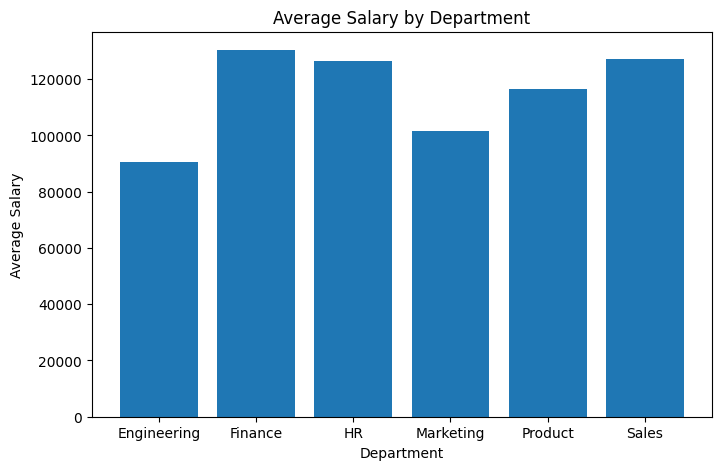

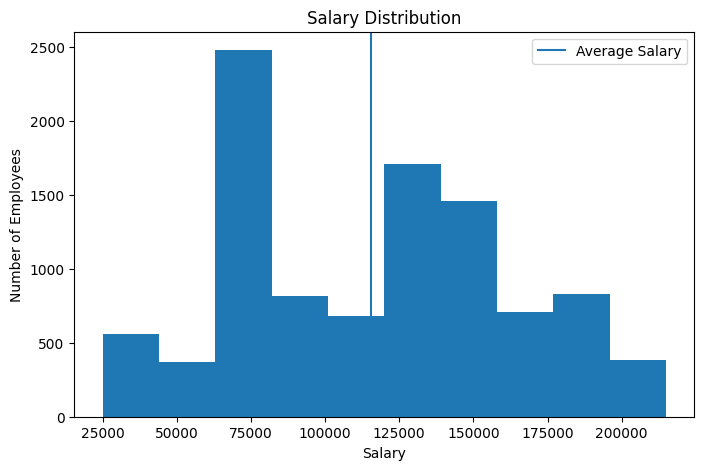

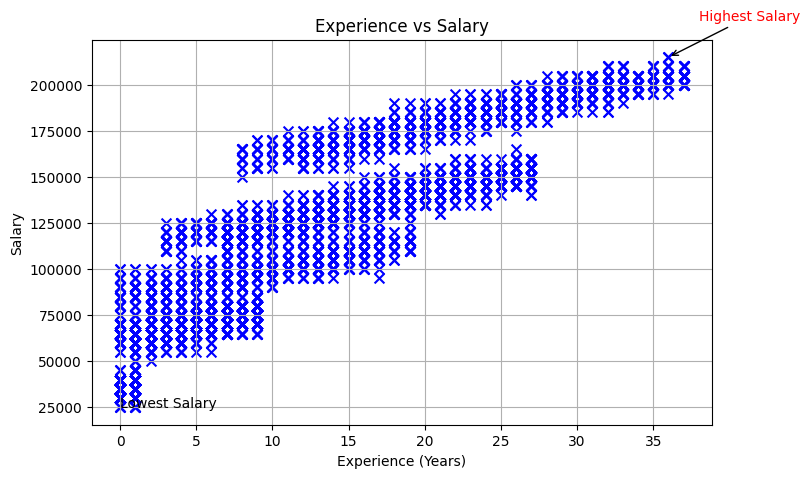

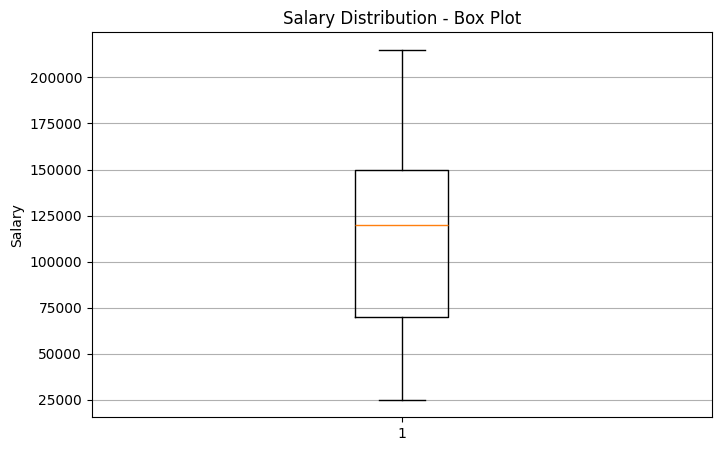

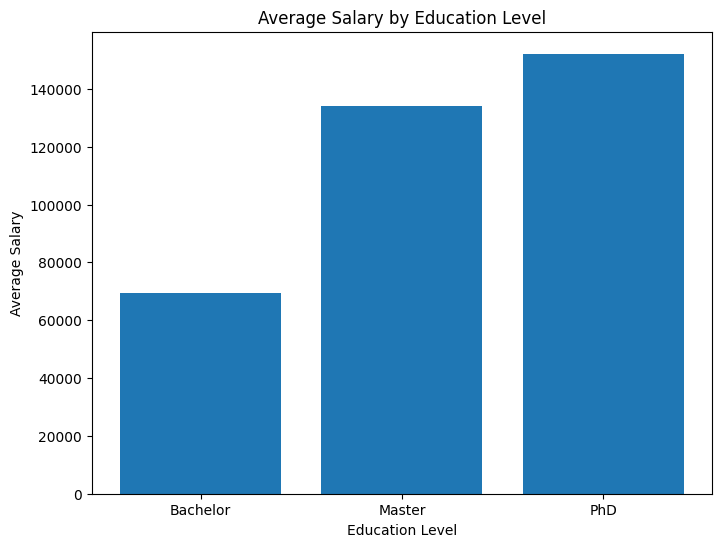

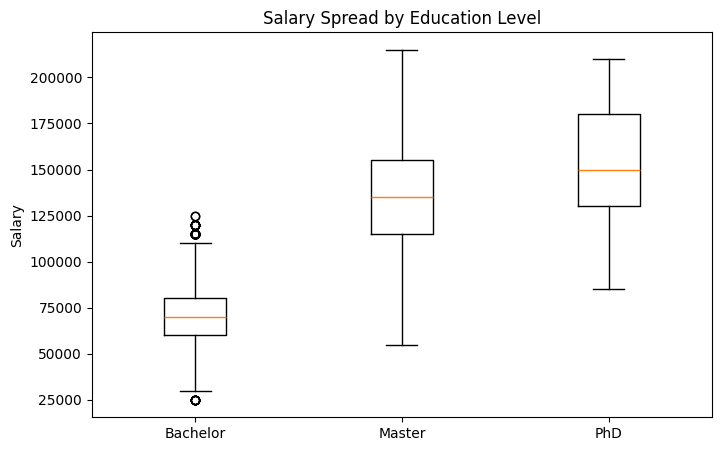

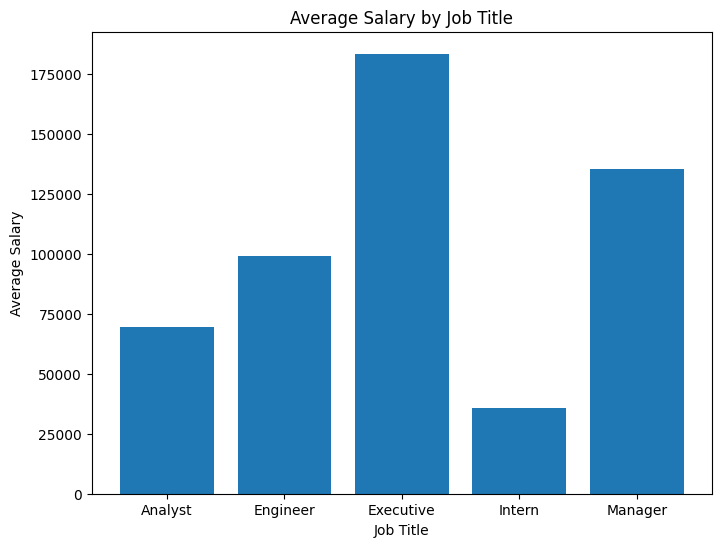

(8000, 7)
(2000, 7)
(8000,)
(2000,)
(10000, 23)
   Age  Experience_Years  Education_Level_Bachelor  Education_Level_Master  \
0   24                 1                     False                    True   
1   56                33                     False                    True   
2   21                 1                      True                   False   
3   30                 9                      True                   False   
4   25                 2                     False                    True   

   Education_Level_PhD  Department_Engineering  Department_Finance  \
0                False                    True               False   
1                False                   False               False   
2                False                    True               False   
3                False                   False                True   
4                False                   False               False   

   Department_HR  Department_Marketing  Department_Product  ..

In [2]:
df = pd.read_csv("employees.csv")

#Part A
#1. Number of rows and columns
df.shape

#2. Missing values in each column
df.isna().sum()

#3. Duplicate rows
df.duplicated().sum()

#4. Numerical columns
df.select_dtypes(include="number").columns

#5. Categorical columns
df.select_dtypes(include="object").columns

#Part B
#6. Average salary by Department
avg_salary_dept = df.groupby("Department")["Salary"].mean()

#7. Average salary by Education_Level
avg_sal_edu = df.groupby("Education_Level")["Salary"].mean()

#8. Average salary by Gender
df.groupby("Gender")["Salary"].mean()

#9. Average salary by Location
df.groupby("Location")["Salary"].mean()

#10. Average salary by Experience_Years
df.groupby("Experience_Years")["Salary"].mean()

#average salary by job title
avg_sal_job = df.groupby("Job_Title")["Salary"].mean()

#Part C
#11. Which department has the highest average salary?
df.groupby("Department")["Salary"].mean().sort_values(ascending=False).index[0]

#12. Which education level has the highest average salary?
df.groupby("Education_Level")["Salary"].mean().sort_values(ascending=False).index[0]

#13. Which location has the highest average salary?
df.groupby("Location")["Salary"].mean().sort_values(ascending=False).index[0]

#14. Which gender has the highest average salary?
df.groupby("Gender")["Salary"].mean().sort_values(ascending=False).index[0]

#15. What happens to average salary as experience increases? Give me your interpretation.
df.groupby("Experience_Years")["Salary"].mean().sort_values(ascending=False).head(10)

df.groupby("Experience_Years")["Salary"].mean().sort_values().head(10)

#As experience years increases, salary increases.

#Part D

df.describe()

df.dtypes
#Which department has the highest maximum salary?
df.groupby("Department")["Salary"].max().sort_values(ascending=False).index[0]

#Does salary differ between Job_Title categories?

df.groupby("Job_Title")["Salary"].mean()

#There is difference between job_titles salary. executive and manager have higher average salaries than the other category.

#Which job title is most common?
df.groupby("Job_Title")["Job_Title"].count().sort_values(ascending=False).index[0]

#Which education level has the highest number of employees?
df.groupby("Education_Level")["Education_Level"].count().sort_values(ascending=False).index[0]

#Bar chart for average salary by department
plt.figure(figsize=(8, 5))
plt.bar(avg_salary_dept.index, avg_salary_dept.values)
plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

# #Salary distribution (histogram)
plt.figure(figsize=(8, 5))
plt.hist(df["Salary"])
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
avg_salary = df["Salary"].mean()
plt.axvline(avg_salary, label = "Average Salary")
plt.legend()
plt.show()

#Experience vs salary
plt.figure(figsize=(8,5))
plt.scatter(df["Experience_Years"], df["Salary"], color="blue",s = 50,  marker = "x")
plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.grid()
max_idx = df["Salary"].idxmax()
x = df.loc[max_idx, "Experience_Years"]
y = df.loc[max_idx, "Salary"]
plt.annotate("Highest Salary", (x, y), color = "red", xytext=(x +2, y +20000), arrowprops = dict(arrowstyle = "->"))
min_idx = df["Salary"].idxmin()
x = df.loc[min_idx, "Experience_Years"]
y = df.loc[min_idx, "Salary"]
plt.annotate("Lowest Salary", (x ,y))
plt.xticks(range(0, 40, 5))
plt.show()

#Salary Distribution(Box Plot)
plt.figure(figsize=(8, 5))
plt.boxplot(df["Salary"])
plt.title("Salary Distribution - Box Plot")
plt.ylabel("Salary")
plt.grid(axis="y")
plt.show()

#Average salary by education level
plt.figure(figsize =(8, 6))
plt.bar(avg_sal_edu.index, avg_sal_edu.values)
plt.title("Average Salary by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Salary")
plt.show()

bach_sal = df[df["Education_Level"] == "Bachelor"]["Salary"]
master_sal = df[df["Education_Level"] == "Master"]["Salary"]
phd_sal = df[df["Education_Level"] == "PhD"]["Salary"]

# #Salary Spread by Education Level
plt.figure(figsize=(8,5))
plt.boxplot([bach_sal, master_sal, phd_sal])
plt.title("Salary Spread by Education Level")
plt.ylabel("Salary")
plt.xticks([1, 2, 3], ["Bachelor", "Master", "PhD"])
plt.show()

#average salary by job title
plt.figure(figsize=(8,6))
plt.bar(avg_sal_job.index, avg_sal_job.values)
plt.title("Average Salary by Job Title")
plt.xlabel("Job Title")
plt.ylabel("Average Salary")
plt.show()

#Train test split
X = df[["Age", "Experience_Years", "Education_Level", "Department", "Job_Title", "Location", "Gender"]]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

#initial encoding experiment using pandas
X_encoded = pd.get_dummies(X, columns=["Education_Level", "Department", "Job_Title", "Location", "Gender"])
print(X_encoded.shape)
print(X_encoded.head())

#initial scaler experiement using StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train[["Age", "Experience_Years"]]
)

X_test_scaled = scaler.transform(
    X_test[["Age", "Experience_Years"]]
)

print(X_train_scaled[:5])

numerical_features = ["Age", "Experience_Years"]

categorical_features = [
    "Education_Level",
    "Department",
    "Job_Title",
    "Location",
    "Gender"
]

print(numerical_features)
print(categorical_features)

#Final preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

#Model implementation
model = LinearRegression()

model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

print(y_pred[:10])

comparison = pd.DataFrame({
    "Actual Salary" : y_test.iloc[:10].values,
    "Predicted Salary" : y_pred[:10]
})

print(comparison)

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

#Decision Tree
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_processed, y_train)
tree_pred = tree_model.predict(X_test_processed)
print(tree_pred[:10])

tree_mae = mean_absolute_error(y_test, tree_pred)
tree_rmse = root_mean_squared_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree MAE:", tree_mae)
print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R2:", tree_r2)

#Random Forest Model
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train_processed, y_train)
forest_pred = forest_model.predict(X_test_processed)
print(forest_pred[:10])

forest_mae = mean_absolute_error(y_test, forest_pred)
forest_rmse = root_mean_squared_error(y_test, forest_pred)
forest_r2 = r2_score(y_test, forest_pred)

print("Random Forest MAE:", forest_mae)
print("Random Forest RMSE:", forest_rmse)
print("Random Forest R2:", forest_r2)

#Model Comparison
model_results = pd.DataFrame({
    "Model" : ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE" : [mae, tree_mae, forest_mae],
    "RMSE" : [rmse, tree_rmse, forest_rmse],
    "R2" : [r2, tree_r2, forest_r2]
})

print(model_results)

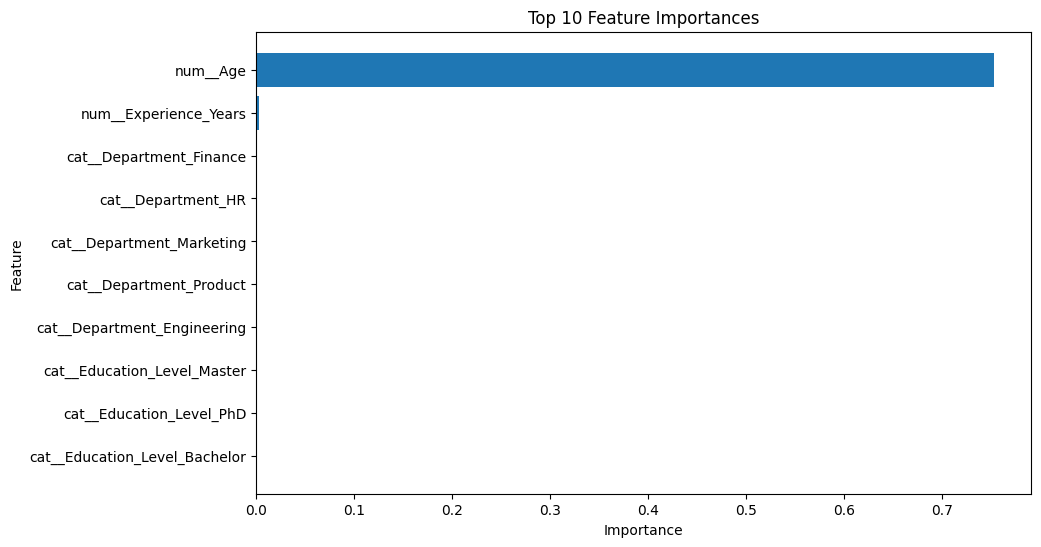

In [3]:
feature_names = preprocessor.get_feature_names_out()
feature_names
importances = forest_model.feature_importances_
importances

importance_df = pd.DataFrame({
    "Feature" : feature_names,
    "Importance" : importances
})
importance_df

top_10 = importance_df.head(10).sort_values(
    by="Importance",
    ascending=False
).head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))
plt.barh(top_10["Feature"], top_10["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()